# Airbnb NYC Price Prediction Workflow

Complete, step-by-step notebook for loading the Airbnb NYC dataset, cleaning it, training baseline regression models, and visualizing performance to support future model improvements.

## 1. Imports & Configuration
Set up libraries used throughout the notebook. Adjust plotting style for consistency.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
DATA_PATH = Path('AB_NYC_2019.csv')
CV_FOLDS = 3
TUNING_ITERATIONS = 4
print(f"Using dataset at: {DATA_PATH.resolve()}")



Using dataset at: /Users/bowen/Desktop/644-project/AB_NYC_2019.csv


## 2. Load & Inspect Data
Preview the raw dataset to understand available columns, data types, and missing values.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Original shape: {raw_df.shape}")
raw_df.head()

Original shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print('Column overview:')
print(raw_df.dtypes)
print('Missing values per column:')
print(raw_df.isna().sum())

Column overview:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object
Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                      

## 3. Data Cleaning
- Fill `reviews_per_month` with 0 since missing implies no recent reviews.
- Drop rows missing critical categorical info (`neighbourhood_group`, `room_type`).
- Keep only positive prices and trim the most extreme 1% tails to reduce noise.

In [4]:
clean_df = raw_df.copy()
clean_df['reviews_per_month'] = clean_df['reviews_per_month'].fillna(0)
clean_df = clean_df.dropna(subset=['neighbourhood_group', 'room_type'])
clean_df = clean_df[clean_df['price'] > 0]
lower = clean_df['price'].quantile(0.01)
upper = clean_df['price'].quantile(0.99)
clean_df = clean_df[(clean_df['price'] >= lower) & (clean_df['price'] <= upper)]
print(f"Cleaned shape: {clean_df.shape}")
clean_df.head()

Cleaned shape: (48017, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 4. Feature & Target Selection
Use geographic, operational, and categorical attributes to predict nightly price.

In [5]:
feature_cols = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'neighbourhood_group',
    'room_type',
]

target_col = 'price'
X = clean_df[feature_cols]
y = clean_df[target_col]
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (48017, 9)
Target vector shape: (48017,)


## 5. Train/Test Split
Reserve 20% of the data for unbiased evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (38413, 9)
Test size: (9604, 9)


## 6. Preprocessing & Model Definitions
Standardize numeric features, one-hot encode categoricals, then configure linear, distance-based, and tree-based regressors inside identical pipelines. We'll also set up k-fold cross-validation (CV) to estimate generalization performance.

In [7]:
numeric_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
]

categorical_features = ['neighbourhood_group', 'room_type']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)


def evaluate_candidate(name, estimator, X_train, X_test, y_train, y_test):
    if isinstance(estimator, RandomizedSearchCV):
        estimator.fit(X_train, y_train)
        fitted_model = estimator.best_estimator_
        cv_mse = -estimator.best_score_
        notes = f"best params: {estimator.best_params_}"
    else:
        cv_scores = cross_val_score(
            estimator,
            X_train,
            y_train,
            cv=CV_FOLDS,
            scoring='neg_mean_squared_error',
            n_jobs=1,
        )
        cv_mse = (-cv_scores).mean()
        fitted_model = estimator.fit(X_train, y_train)
        notes = ''

    train_pred = fitted_model.predict(X_train)
    test_pred = fitted_model.predict(X_test)

    return {
        'Model': name,
        'Train MSE': mean_squared_error(y_train, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred),
        'Test RMSE': mean_squared_error(y_test, test_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test R2': r2_score(y_test, test_pred),
        f'CV MSE ({CV_FOLDS}-fold)': cv_mse,
        'Notes': notes,
        'fitted_model': fitted_model,
    }


models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression()),
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0)),
    ]),
    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.1, max_iter=10000)),
    ]),
    'KNN Regression (distance, k=15)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(n_neighbors=15, weights='distance')),
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=None, random_state=42)),
    ]),
    'Random Forest Baseline': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)),
    ]),
    'Gradient Boosting Baseline': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(random_state=42)),
    ]),
    'Gradient Boosting + log(price)': Pipeline([
        ('preprocessor', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=GradientBoostingRegressor(
                random_state=42,
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
            ),
            func=np.log1p,
            inverse_func=np.expm1,
        )),
    ]),
}

tuned_models = {
    'Random Forest Tuned': RandomizedSearchCV(
        estimator=Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(random_state=42, n_jobs=1)),
        ]),
        param_distributions={
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [12, 16, 20, None],
            'model__min_samples_leaf': [1, 2, 5],
            'model__max_features': ['sqrt', None],
        },
        n_iter=TUNING_ITERATIONS,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=1,
    ),
    'Gradient Boosting Tuned': RandomizedSearchCV(
        estimator=Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(random_state=42)),
        ]),
        param_distributions={
            'model__n_estimators': [150, 300, 500],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__max_depth': [2, 3, 4],
            'model__subsample': [0.7, 0.8, 1.0],
            'model__min_samples_leaf': [1, 2, 5],
        },
        n_iter=TUNING_ITERATIONS,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=1,
    ),
}

list(models.keys()) + list(tuned_models.keys())



['Linear Regression',
 'Ridge Regression',
 'Lasso Regression',
 'KNN Regression (distance, k=15)',
 'Decision Tree',
 'Random Forest Baseline',
 'Gradient Boosting Baseline',
 'Gradient Boosting + log(price)',
 'Random Forest Tuned',
 'Gradient Boosting Tuned']

## 7. Train & Evaluate Models
Fit each pipeline, compute train/test Mean Squared Error, and compare results.

In [8]:
results = []
trained_models = {}
cv_col = f'CV MSE ({CV_FOLDS}-fold)'

for name, estimator in models.items():
    result = evaluate_candidate(name, estimator, X_train, X_test, y_train, y_test)
    trained_models[name] = result.pop('fitted_model')
    results.append(result)

for name, estimator in tuned_models.items():
    result = evaluate_candidate(name, estimator, X_train, X_test, y_train, y_test)
    trained_models[name] = result.pop('fitted_model')
    results.append(result)

results_df = pd.DataFrame(results).sort_values(cv_col).reset_index(drop=True)
results_df


,Model,Train MSE,Test MSE,Test RMSE,Test MAE,Test R2,CV MSE (3-fold),Notes
0,Random Forest Tuned,2675.617450,5493.192187,74.116072,44.729524,0.492291,5389.129758,"best params: {'model__n_estimators': 200, 'mod..."
1,Gradient Boosting Tuned,4361.382936,5546.183586,74.472704,45.628588,0.487393,5505.502369,"best params: {'model__subsample': 0.8, 'model_..."
2,Random Forest Baseline,760.533809,5695.473079,75.468358,46.219044,0.473595,5644.504777,
3,"KNN Regression (distance, k=15)",0.032541,5935.191551,77.040194,46.855716,0.451439,5811.721195,
4,Gradient Boosting Baseline,5729.688234,6037.340764,77.700327,47.392218,0.441998,5861.969223,
5,Gradient Boosting + log(price),5943.483503,6277.311827,79.229488,44.266192,0.419819,6062.256447,
6,Ridge Regression,6931.956754,7118.057499,84.368581,53.173501,0.342113,6938.974179,
7,Linear Regression,6931.955498,7118.065744,84.368630,53.175114,0.342112,6938.982285,
8,Lasso Regression,6935.113577,7121.084771,84.386520,53.110696,0.341833,6942.047684,
9,Decision Tree,0.032541,11233.177114,105.986684,62.358496,-0.038227,11009.584822,


In [9]:
best_model_name = results_df.loc[0, 'Model']
print(f"Best model by {cv_col}: {best_model_name}")
print(results_df.loc[0, ['Test MSE', 'Test RMSE', 'Test MAE', 'Test R2', cv_col, 'Notes']])


Best model by CV MSE (3-fold): Random Forest Tuned
Test MSE                                                 5493.192187
Test RMSE                                                  74.116072
Test MAE                                                   44.729524
Test R2                                                     0.492291
CV MSE (3-fold)                                          5389.129758
Notes              best params: {'model__n_estimators': 200, 'mod...
Name: 0, dtype: object


## 8. Visualizations
1. Bar chart comparing Train/Test MSE.
2. Scatter plot of actual vs. predicted prices for the best model.

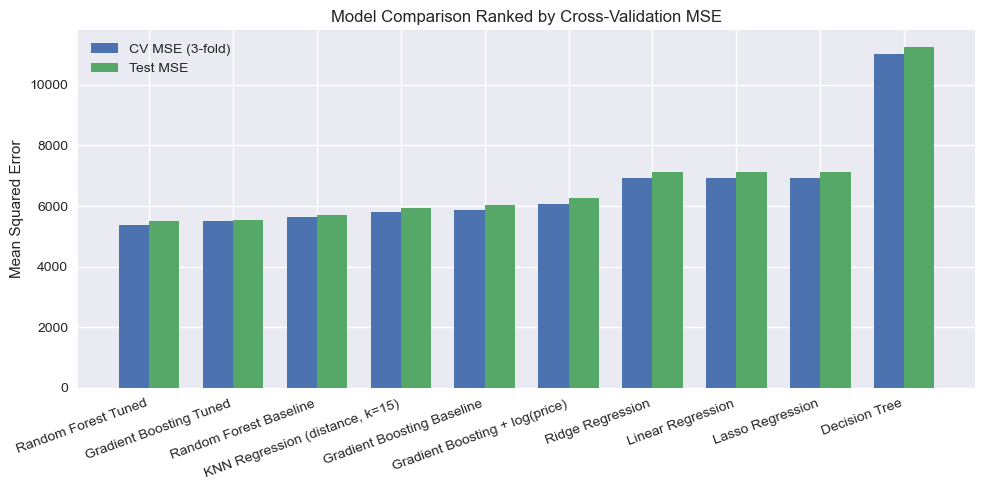

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(results_df))
ax.bar(x_pos - 0.18, results_df[cv_col], width=0.36, label=cv_col)
ax.bar(x_pos + 0.18, results_df['Test MSE'], width=0.36, label='Test MSE')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Model Comparison Ranked by Cross-Validation MSE')
ax.legend()
plt.tight_layout()
plt.show()



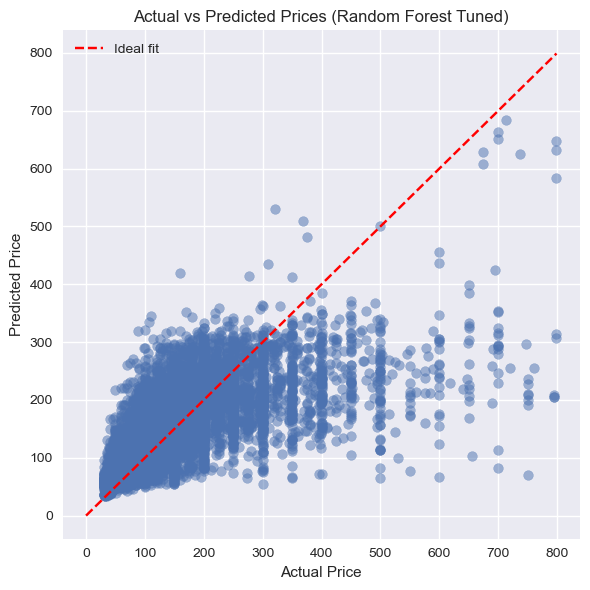

In [11]:
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.5)
max_val = max(y_test.max(), best_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Prices ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.show()



## 9. Next Steps
- Tune hyperparameters (e.g., Ridge/Lasso alphas, KNN neighbors, tree depth, forest size, learning rate) via GridSearchCV/RandomizedSearchCV.
- Engineer richer features (text sentiment, neighbourhood-level stats, temporal signals) and re-train the expanded model set.
- Explore advanced ensembles (e.g., XGBoost/LightGBM) or stacking models to push Test MSE lower once strong single models are identified.